# 07 -- Joint Hurdle BiLSTM

Главная идея -- не учить classifier и regressor как две независимые сети. Один shared encoder сразу оптимизирует итоговый прогноз в `log1p`-пространстве.

Финальный сабмит:

[lstm_hurdle_v4_robust.csv](/submissions/lstm_hurdle_v4_robust.csv)

**Public RMSLE: 1.6509102971.**

## Что изменилось относительно изначальной Hurdle BiLSTM

Изначальная сильная версия была такой:

```text
sequence -> BiLSTM -> last/mean/max
                         \
                          -> fusion -> classifier
static -> MLP            /

sequence -> BiLSTM -> last/mean/max
                         \
                          -> fusion -> positive regressor
static -> MLP            /
```

Classifier и regressor были двумя независимыми `HybridLSTM` с разными весами.

Финальный прогноз:

`pred_log = P(GMV > 0) * positive_log`.

Что поменял:

- две независимые сети -> один shared encoder;
- отдельный BCE-classifier и positive-only regressor -> три головы на общем representation;
- добавил `direct_head`, который сразу предсказывает итоговый `log1p(GMV)`;
- hurdle и direct смешиваются обучаемым весом `w`;
- главный loss считается по финальному `pred_log`, а не по двум независимым surrogate-задачам;
- `BatchNorm` перед sequence -> `LayerNorm` после projection;
- `Linear(96) + BiLSTM(hidden=128)` -> `Linear(80) + BiLSTM(hidden=112)`;
- pooling `last + mean + max` -> `last + masked mean + masked max + attention`;
- добавил recency bias в attention;
- left padding больше не проходит через LSTM как настоящая история -- использую `history_length`, mask и `pack_padded_sequence`;
- добавил отдельную short-summary ветку на окнах 1/3/7/14/30/60/90 дней;
- sequence выросла с 40 до 53 признаков на день;
- static preprocessing теперь фитится отдельно на train части каждого temporal fold;
- `user_id` embedding оставил optional, но в финальном run выключил;
- future-horizon calendar оставил optional, но в финальном run выключил;
- conv stem оставил optional, но в финальном run выключил;
- число эпох выбираю по 3 expanding temporal folds, а не по одному последнему cutoff;
- final prediction -- log-space ensemble двух seed;
- checkpoint сохраняю после каждой эпохи.

Главное изменение -- модель напрямую оптимизирует тот `pred_log`, который потом идет в RMSLE.

**Новая архитектура:**

Текущая архитектура:

```text
sequence (53/day)
    |
    -> Linear(80) -> LayerNorm -> GELU
    |
    -> 2-layer BiLSTM(hidden=112)
    |
    -> last / masked mean / masked max / attention
    |
    -> sequence head -> 144
                           \
short summary (93)          \
    |                        \
    -> MLP -> 64              \
                               -> concat -> fusion -> 96
static (235)                 /                  |
    |                       /                   |
    -> MLP -> 96           /                    |
                                               / | \
                                              /  |  \
                                             /   |   \
                                            /    |    \
                                      gate_head  |  direct_head
                                          |      |      |
                                     P(GMV > 0)  |  direct_log
                                                 |
                                           positive_head
                                                 |
                                           positive_log
```

`hurdle_log = P(GMV > 0) * positive_log`

```text
                       hurdle_log
                           \
                            -> learned blend -> pred_log
                           /
                      direct_log
```

`pred_log = w * hurdle_log + (1 - w) * direct_log`


In [1]:
from pathlib import Path
import hashlib
import json
import math
import random
import shutil

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
from sklearn.metrics import roc_auc_score
from torch import nn
from torch.nn.utils.rnn import pack_padded_sequence, pad_packed_sequence
from torch.utils.data import ConcatDataset, DataLoader, Dataset


def find_project_root():
    for path in [Path.cwd(), *Path.cwd().parents]:
        if (path / "data" / "lstm" / "meta.json").exists():
            return path
    raise FileNotFoundError(
        "Не найден data/lstm/meta.json. Сначала запустите обновленный 06_LSTM_Data_Preparation.ipynb."
    )


PROJECT_ROOT = find_project_root()
DATA_DIR = PROJECT_ROOT / "data" / "lstm"
MODEL_DIR = PROJECT_ROOT / "models" / "lstm_hurdle_v4_robust"
SUBMISSION_DIR = PROJECT_ROOT / "submissions"
MODEL_DIR.mkdir(parents=True, exist_ok=True)
SUBMISSION_DIR.mkdir(parents=True, exist_ok=True)

with open(DATA_DIR / "meta.json", encoding="utf-8") as f:
    META = json.load(f)

if META.get("format_version") != 2:
    raise RuntimeError(
        "LSTM v4 ожидает data format v2. Перезапустите обновленный 06_LSTM_Data_Preparation.ipynb."
    )

LABELED_CUTOFFS = META["labeled_cutoffs"]
INFERENCE_CUTOFF = META["inference_cutoff"]
BASE_SEQUENCE_FEATURES = META["base_sequence_features"]
CALENDAR_FEATURES = META["calendar_sequence_features"]
RAW_STATIC_FEATURES = META["static_features"]
RAW_STATIC_LOG_FEATURES = META["static_log_copy_features"]
EXTRA_STATIC_FEATURES = set(META.get("extra_static_features", []))
SEQ_LEN = int(META["seq_len"])
N_USERS = int(META["user_count"])

BASE_INDEX = {name: i for i, name in enumerate(BASE_SEQUENCE_FEATURES)}

# Флаги меняю по одному после baseline run.
USE_USER_EMBEDDING = False
USER_EMBED_DIM = 4
USE_CONV_STEM = False

USE_ABSOLUTE_TIME = True
USE_FUTURE_CALENDAR_STATIC = False
USE_CUTOFF_SEASONAL_STATIC = False

BATCH_SIZE = 768
MAX_CV_EPOCHS = 6
N_CV_FOLDS = 3
LR = 3.5e-4
EMBED_LR = 1.0e-4
WEIGHT_DECAY = 1.2e-3
EMBED_WEIGHT_DECAY = 8e-3
RANDOM_STATE = 42
FINAL_SEEDS = [42, 143]

AUX_GATE_WEIGHT = 0.03
AUX_POS_WEIGHT = 0.10
AUX_DIRECT_WEIGHT = 0.05

REFERENCE_JAN_HOLDOUT_RMSLE = 1.679061
AUTO_SKIP_FINAL_IF_WEAK = True
MAX_JAN_DEGRADATION_FOR_FINAL = 0.015
FORCE_FINAL_TRAIN = False

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available()
    else "cpu"
)
NUM_WORKERS = 4 if DEVICE.type == "cuda" else 0
USE_AMP = DEVICE.type == "cuda"


def set_seed(seed=RANDOM_STATE):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def choose_static_features():
    selected = []
    for name in RAW_STATIC_FEATURES:
        if name not in EXTRA_STATIC_FEATURES:
            selected.append(name)
            continue

        if name == "cutoff_time_years" and USE_ABSOLUTE_TIME:
            selected.append(name)
        elif name.startswith("forecast_") and USE_FUTURE_CALENDAR_STATIC:
            selected.append(name)
        elif (
            name.startswith("cutoff_")
            and name != "cutoff_time_years"
            and USE_CUTOFF_SEASONAL_STATIC
        ):
            selected.append(name)
    return selected


STATIC_FEATURES = choose_static_features()
STATIC_INDICES = np.array(
    [RAW_STATIC_FEATURES.index(name) for name in STATIC_FEATURES],
    dtype=np.int64,
)
STATIC_LOG_FEATURES = [name for name in RAW_STATIC_LOG_FEATURES if name in STATIC_FEATURES]
STATIC_LOG_INDICES = [STATIC_FEATURES.index(name) for name in STATIC_LOG_FEATURES]

set_seed()
print("device:", DEVICE)
print("AMP:", USE_AMP)
print("labeled cutoffs:", LABELED_CUTOFFS)
print("CV validation cutoffs:", LABELED_CUTOFFS[-N_CV_FOLDS:])
print("inference:", INFERENCE_CUTOFF)
print("users:", N_USERS)
print("static features:", len(STATIC_FEATURES), "/", len(RAW_STATIC_FEATURES))
print("user embedding:", USE_USER_EMBEDDING)
print("future calendar static:", USE_FUTURE_CALENDAR_STATIC)

device: mps
AMP: False
labeled cutoffs: ['2025-04-19', '2025-05-19', '2025-06-18', '2025-07-18', '2025-08-17', '2025-09-16', '2025-10-16', '2025-11-15', '2025-12-15', '2026-01-14']
CV validation cutoffs: ['2025-11-15', '2025-12-15', '2026-01-14']
inference: 2026-02-13
users: 250000
static features: 92 / 103
user embedding: False
future calendar static: False


## Dataset и variable-length history

`HybridDataset` возвращает:

- 90-дневную sequence;
- static-признаки;
- `user_index`;
- `user_known`;
- `history_length`;
- target для train cutoff.

`history_length` отделяет реальную историю от pre-first-seen padding.

Если `user_id` embedding включен, unseen user на validation/inference получает нулевой embedding. В финальном run embedding выключен.

In [3]:
def known_user_mask_from_cutoffs(cutoffs):
    mask = np.zeros(N_USERS, dtype=np.bool_)
    for cutoff in cutoffs:
        idx = np.load(DATA_DIR / cutoff / "user_index.npy", mmap_mode="r")
        mask[np.asarray(idx, dtype=np.int64)] = True
    return mask


class HybridDataset(Dataset):
    def __init__(self, cutoff, with_target=True, known_user_mask=None):
        path = DATA_DIR / cutoff
        self.X = np.load(path / "X.npy", mmap_mode="r")
        self.static = np.load(path / "static.npy", mmap_mode="r")
        self.calendar = np.load(path / "calendar.npy", mmap_mode="r").astype(np.float32)
        self.users = np.load(path / "user_id.npy", mmap_mode="r")
        self.user_index = np.load(path / "user_index.npy", mmap_mode="r")
        self.history_length = np.load(path / "history_length.npy", mmap_mode="r")
        self.y = np.load(path / "y.npy", mmap_mode="r") if with_target else None
        self.known_user_mask = known_user_mask

    def __len__(self):
        return len(self.X)

    def __getitem__(self, i):
        sequence = np.concatenate([
            np.asarray(self.X[i], dtype=np.float32),
            self.calendar,
        ], axis=1)

        user_index = int(self.user_index[i])
        user_known = True if self.known_user_mask is None else bool(self.known_user_mask[user_index])

        raw_static = np.asarray(self.static[i], dtype=np.float32)
        static = raw_static[STATIC_INDICES]

        result = (
            torch.from_numpy(sequence),
            torch.from_numpy(static),
            torch.tensor(user_index, dtype=torch.long),
            torch.tensor(user_known, dtype=torch.bool),
            torch.tensor(int(self.history_length[i]), dtype=torch.long),
        )

        if self.y is None:
            return result

        return (*result, torch.tensor(float(self.y[i]), dtype=torch.float32))


def make_loader(
    cutoffs,
    shuffle=False,
    with_target=True,
    batch_size=BATCH_SIZE,
    known_user_mask=None,
):
    if isinstance(cutoffs, str):
        cutoffs = [cutoffs]

    dataset = ConcatDataset([
        HybridDataset(
            cutoff,
            with_target=with_target,
            known_user_mask=known_user_mask,
        )
        for cutoff in cutoffs
    ])

    return DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=shuffle,
        num_workers=NUM_WORKERS,
        pin_memory=DEVICE.type == "cuda",
        persistent_workers=NUM_WORKERS > 0,
        drop_last=False,
    )

## Признаки

### Sequence -- 53 признака на каждый из 90 дней

19 признаков приходят с диска:

- 13 базовых дневных -- `search`, `cat`, `searches`, переходы, `to_cart`, `to_ord`, GMV и `active`;
- 6 calendar -- sin/cos для дня недели, дня месяца и дня года.

Еще 34 считаю на батче:

- `valid_mask` -- реальная история, без pre-first-seen padding;
- `relative_history_position` -- позиция дня внутри реальной истории;
- `days_to_cutoff` -- нормированное расстояние до cutoff;
- 4 `has_*` -- были ли `search_to_cart`, `search_to_ord`, `cat_to_cart`, `cat_to_ord`;
- 4 ratio -- `search_to_cart/searches`, `search_to_ord/searches`, `to_ord/to_cart`, `gmv_search/gmv`;
- rolling mean 3/7/14/30 дней для `searches`, `to_cart`, `to_ord`, `gmv` -- 16 признаков;
- rolling activity rate 3/7/14/30 -- 4 признака;
- first difference для `searches`, `to_ord`, `gmv` -- 3 признака.

Все rolling и difference считают только валидную историю до cutoff.

### Short summary -- 93 признака на пользователя

Отдельно от BiLSTM считаю summary по последним окнам:

- `log1p(sum)` за 1/3/7/14/30/60/90 дней для `searches`, `to_cart`, `to_ord`, `gmv`, `gmv_search` -- 35;
- activity rate на тех же окнах -- 7;
- days since last event для этих 5 сигналов -- 5;
- recent minus previous за 3/7/14/30 дней для этих 5 сигналов -- 20;
- три непересекающихся 30-дневных bucket + разница recent vs old для этих 5 сигналов -- 20;
- purchase periodicity -- event rate, days since last order, last order gap, phase, наличие двух покупок -- 5;
- `history_length / 90` -- 1.

### Static -- 235 признаков после preprocessing

В финальном run беру:

- 91 исходный признак из `Prepared_data.parquet`;
- `cutoff_time_years` -- один smooth absolute-time признак;
- 51 `log1p`-копию heavy-tail static-признаков;
- 92 missing-mask.

Future-horizon calendar и cutoff-seasonal static по умолчанию выключены.

Причина -- таких значений всего 10 по train cutoff, поэтому богатый calendar легко начинает работать как cutoff ID.

In [4]:
def history_mask_from_lengths(lengths, steps=SEQ_LEN):
    positions = torch.arange(steps, device=lengths.device).unsqueeze(0)
    starts = steps - lengths.unsqueeze(1)
    return positions >= starts


def causal_masked_mean(values, valid_mask, window):
    values = values * valid_mask
    num = F.avg_pool1d(
        F.pad(values.unsqueeze(1), (window - 1, 0)),
        window,
        stride=1,
    ).squeeze(1) * window
    den = F.avg_pool1d(
        F.pad(valid_mask.unsqueeze(1), (window - 1, 0)),
        window,
        stride=1,
    ).squeeze(1) * window
    return num / den.clamp_min(1.0)


def first_difference(values, valid_mask):
    previous_valid = F.pad(valid_mask[:, :-1], (1, 0))
    both_valid = valid_mask * previous_valid
    diff = F.pad(values[:, 1:] - values[:, :-1], (1, 0))
    return diff * both_valid


def safe_ratio(numerator, denominator, max_value=5.0):
    ratio = numerator / denominator.clamp_min(1e-3)
    ratio = torch.where(denominator > 0, ratio, torch.zeros_like(ratio))
    return ratio.clamp(0, max_value)


def make_sequence_features(x, lengths):
    steps = x.shape[1]
    valid_mask = history_mask_from_lengths(lengths, steps).float()

    searches_log = x[..., BASE_INDEX["searches"]]
    search_to_cart_log = x[..., BASE_INDEX["search_to_cart"]]
    search_to_ord_log = x[..., BASE_INDEX["search_to_ord"]]
    cat_to_cart_log = x[..., BASE_INDEX["cat_to_cart"]]
    cat_to_ord_log = x[..., BASE_INDEX["cat_to_ord"]]
    to_cart_log = x[..., BASE_INDEX["to_cart"]]
    to_ord_log = x[..., BASE_INDEX["to_ord"]]
    gmv_search_log = x[..., BASE_INDEX["gmv_search"]]
    gmv_log = x[..., BASE_INDEX["gmv"]]
    active = x[..., BASE_INDEX["active"]]

    searches = torch.expm1(searches_log).clamp_min(0)
    search_to_cart = torch.expm1(search_to_cart_log).clamp_min(0)
    search_to_ord = torch.expm1(search_to_ord_log).clamp_min(0)
    cat_to_cart = torch.expm1(cat_to_cart_log).clamp_min(0)
    cat_to_ord = torch.expm1(cat_to_ord_log).clamp_min(0)
    to_cart = torch.expm1(to_cart_log).clamp_min(0)
    to_ord = torch.expm1(to_ord_log).clamp_min(0)
    gmv_search = torch.expm1(gmv_search_log).clamp_min(0)
    gmv = torch.expm1(gmv_log).clamp_min(0)

    positions = torch.arange(steps, device=x.device).float().unsqueeze(0)
    starts = (steps - lengths).float().unsqueeze(1)
    denom = (lengths.float() - 1).clamp_min(1.0).unsqueeze(1)

    relative_history_position = ((positions - starts) / denom).clamp(0, 1) * valid_mask
    days_to_cutoff = ((steps - 1 - positions) / max(steps - 1, 1)) * valid_mask

    derived = [
        valid_mask,
        relative_history_position,
        days_to_cutoff,
        (search_to_cart > 0).float(),
        (search_to_ord > 0).float(),
        (cat_to_cart > 0).float(),
        (cat_to_ord > 0).float(),
        safe_ratio(search_to_cart, searches),
        safe_ratio(search_to_ord, searches),
        safe_ratio(to_ord, to_cart),
        safe_ratio(gmv_search, gmv, 1.5),
    ]

    for values in [searches_log, to_cart_log, to_ord_log, gmv_log]:
        for window in [3, 7, 14, 30]:
            derived.append(causal_masked_mean(values, valid_mask, window))

    for window in [3, 7, 14, 30]:
        derived.append(causal_masked_mean(active, valid_mask, window))

    for values in [searches_log, to_ord_log, gmv_log]:
        derived.append(first_difference(values, valid_mask))

    return torch.cat([x, torch.stack(derived, dim=-1)], dim=-1)


def _raw_channel(x, feature_name):
    return torch.expm1(x[..., BASE_INDEX[feature_name]]).clamp_min(0)


def _window_raw_sum(x, feature_name, window):
    return _raw_channel(x, feature_name)[:, -window:].sum(dim=1)


def _slice_raw_sum(x, feature_name, start_from_end, end_from_end):
    values = _raw_channel(x, feature_name)
    left = x.shape[1] - start_from_end
    right = x.shape[1] - end_from_end if end_from_end > 0 else x.shape[1]
    return values[:, max(left, 0):max(right, 0)].sum(dim=1)


def _days_since_event(x, lengths, feature_name):
    values = _raw_channel(x, feature_name)
    valid = history_mask_from_lengths(lengths, x.shape[1])
    event = (values > 0) & valid
    positions = torch.arange(x.shape[1], device=x.device).unsqueeze(0).expand_as(values)
    last = torch.where(event, positions, torch.full_like(positions, -1)).amax(dim=1)
    days = (x.shape[1] - 1 - last).float()
    return torch.where(last >= 0, days / x.shape[1], torch.full_like(days, 1.25))


def _purchase_periodicity(x, lengths):
    values = _raw_channel(x, "to_ord")
    valid = history_mask_from_lengths(lengths, x.shape[1])
    event = (values > 0) & valid

    positions = torch.arange(x.shape[1], device=x.device).unsqueeze(0).expand_as(values)
    masked_pos = torch.where(event, positions, torch.full_like(positions, -1))
    top2 = torch.topk(masked_pos, k=2, dim=1).values
    last = top2[:, 0]
    previous = top2[:, 1]

    has_any = last >= 0
    has_two = previous >= 0

    days_since = torch.where(
        has_any,
        (x.shape[1] - 1 - last).float() / x.shape[1],
        torch.full_like(last.float(), 1.25),
    )
    last_gap = torch.where(
        has_two,
        (last - previous).float() / x.shape[1],
        torch.ones_like(last.float()),
    )
    event_rate = event.sum(dim=1).float() / lengths.float().clamp_min(1.0)
    phase = torch.where(
        has_two,
        days_since / last_gap.clamp_min(1.0 / x.shape[1]),
        torch.ones_like(days_since),
    ).clamp(0, 5)

    return [event_rate, days_since, last_gap, phase, has_two.float()]


def make_short_summary(x, lengths):
    windows = [1, 3, 7, 14, 30, 60, 90]
    volume_names = ["searches", "to_cart", "to_ord", "gmv", "gmv_search"]
    features = []

    for name in volume_names:
        for window in windows:
            features.append(torch.log1p(_window_raw_sum(x, name, window)))

    active = x[..., BASE_INDEX["active"]]
    for window in windows:
        exposure = lengths.clamp(max=window).float()
        features.append(active[:, -window:].sum(dim=1) / exposure.clamp_min(1.0))

    for name in volume_names:
        features.append(_days_since_event(x, lengths, name))

    for name in volume_names:
        values = _raw_channel(x, name)
        for window in [3, 7, 14, 30]:
            recent = values[:, -window:].sum(dim=1)
            previous = values[:, -2 * window:-window].sum(dim=1)
            features.append(torch.log1p(recent) - torch.log1p(previous))

    for name in volume_names:
        buckets = [
            _slice_raw_sum(x, name, 30, 0),
            _slice_raw_sum(x, name, 60, 30),
            _slice_raw_sum(x, name, 90, 60),
        ]
        bucket_logs = [torch.log1p(v) for v in buckets]
        features.extend(bucket_logs)
        features.append(bucket_logs[0] - bucket_logs[2])

    features.extend(_purchase_periodicity(x, lengths))
    features.append(lengths.float() / x.shape[1])

    return torch.stack(features, dim=1)


with torch.no_grad():
    dummy_x = torch.zeros(
        2,
        SEQ_LEN,
        len(BASE_SEQUENCE_FEATURES) + len(CALENDAR_FEATURES),
        dtype=torch.float32,
    )
    dummy_lengths = torch.tensor([SEQ_LEN, max(2, SEQ_LEN // 2)], dtype=torch.long)
    SEQ_INPUT_SIZE = int(make_sequence_features(dummy_x, dummy_lengths).shape[-1])
    SHORT_SUMMARY_SIZE = int(make_short_summary(dummy_x, dummy_lengths).shape[-1])

print("sequence features:", SEQ_INPUT_SIZE)
print("short summary:", SHORT_SUMMARY_SIZE)

sequence features: 53
short summary: 93


## Static preprocessing

На каждом CV fold preprocessing фитится только по train cutoff.

Схема:

- выбираю 92 raw static-признака;
- добавляю 51 `log1p`-копию heavy-tail признаков;
- добавляю 92 missing-mask;
- пропуски заменяю train mean;
- стандартизую train mean/std.

Validation в расчет mean/std не попадает.

In [5]:
STATIC_INPUT_SIZE = 2 * len(STATIC_FEATURES) + len(STATIC_LOG_INDICES)


def augment_static_numpy(raw):
    raw = np.asarray(raw, dtype=np.float32)
    source = raw[:, STATIC_LOG_INDICES]
    logs = np.where(
        np.isfinite(source),
        np.log1p(np.clip(source, 0, None)),
        np.nan,
    ).astype(np.float32)
    missing = (~np.isfinite(raw)).astype(np.float32)
    return np.concatenate([raw, logs, missing], axis=1)


def fit_static_stats(cutoffs, chunk_size=65_536):
    sums = np.zeros(STATIC_INPUT_SIZE, dtype=np.float64)
    sums_sq = np.zeros(STATIC_INPUT_SIZE, dtype=np.float64)
    counts = np.zeros(STATIC_INPUT_SIZE, dtype=np.int64)

    for cutoff in cutoffs:
        raw_full = np.load(DATA_DIR / cutoff / "static.npy", mmap_mode="r")
        for start in range(0, len(raw_full), chunk_size):
            raw = np.asarray(raw_full[start:start + chunk_size], dtype=np.float32)[:, STATIC_INDICES]
            block = augment_static_numpy(raw)
            finite = np.isfinite(block)
            safe = np.where(finite, block, 0.0).astype(np.float64)
            sums += safe.sum(axis=0)
            sums_sq += (safe * safe).sum(axis=0)
            counts += finite.sum(axis=0)

    counts = np.maximum(counts, 1)
    mean = sums / counts
    std = np.sqrt(np.maximum(sums_sq / counts - mean * mean, 1e-6))
    return (
        torch.tensor(mean, dtype=torch.float32),
        torch.tensor(std, dtype=torch.float32),
    )


def normalize_static(raw, stats):
    source = raw[:, STATIC_LOG_INDICES]
    logs = torch.where(
        torch.isfinite(source),
        torch.log1p(source.clamp_min(0)),
        torch.nan,
    )
    augmented = torch.cat([raw, logs, (~torch.isfinite(raw)).float()], dim=1)

    mean, std = stats
    mean = mean.to(raw.device)
    std = std.to(raw.device)

    augmented = torch.where(torch.isfinite(augmented), augmented, mean)
    return (augmented - mean) / std


print("static features after augmentation:", STATIC_INPUT_SIZE)

static features after augmentation: 235


## Текущая архитектура

Sequence-ветка:

`53/day -> Linear(80) -> LayerNorm -> GELU -> 2-layer BiLSTM(hidden=112)`

После BiLSTM беру четыре pooling:

- last hidden;
- masked mean;
- masked max;
- attention pooling с обучаемым recency bias.

Их concat идет в `sequence_head -> 144`.

Отдельные ветки:

- `short summary: 93 -> 96 -> 64`;
- `static: 235 -> 192 -> 96`;
- optional `user_id` embedding -- в финальном run выключен.

После concat:

`144 + 64 + 96 -> fusion -> 96`

Из общего representation выходят три головы:

- `gate_head` -- `P(GMV > 0)`;
- `positive_head` -- `log1p(GMV)` для положительной части;
- `direct_head` -- прямой прогноз `E[log1p(GMV) | x]`.

Hurdle-прогноз:

$$
\hat z_{hurdle}=P(GMV>0)\cdot \hat z_{positive}.
$$

Финальный прогноз:

$$
\hat z=w\hat z_{hurdle}+(1-w)\hat z_{direct},
$$

где `w` -- обучаемый scalar.

Conv stem и `user_id` embedding оставлены в коде только как отдельные ablation. В финальном run оба выключены.

In [6]:
def compact_left_padded(sequence, lengths):
    # Left padding переношу вправо перед packing.
    batch, steps, channels = sequence.shape
    positions = torch.arange(steps, device=sequence.device).unsqueeze(0).expand(batch, -1)
    starts = steps - lengths.unsqueeze(1)
    source_pos = (positions + starts).clamp(max=steps - 1)
    gathered = sequence.gather(
        1,
        source_pos.unsqueeze(-1).expand(-1, -1, channels),
    )
    valid = positions < lengths.unsqueeze(1)
    return gathered * valid.unsqueeze(-1)


class ResidualConvBlock(nn.Module):
    def __init__(self, channels, kernel_size=5, dropout=0.10):
        super().__init__()
        padding = kernel_size // 2
        self.conv1 = nn.Conv1d(channels, channels, kernel_size, padding=padding)
        self.conv2 = nn.Conv1d(channels, channels, 3, padding=1)
        self.norm1 = nn.LayerNorm(channels)
        self.norm2 = nn.LayerNorm(channels)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, valid_mask):
        residual = x
        y = self.conv1(x.transpose(1, 2)).transpose(1, 2)
        y = self.norm1(y)
        y = F.gelu(y)
        y = self.dropout(y)
        y = self.conv2(y.transpose(1, 2)).transpose(1, 2)
        y = self.norm2(y)
        y = F.gelu(y)
        y = self.dropout(y)
        return (residual + y) * valid_mask.unsqueeze(-1)


class JointHurdleLSTM(nn.Module):
    def __init__(
        self,
        n_users,
        user_embed_dim=0,
        d_model=80,
        hidden_size=112,
        num_layers=2,
        lstm_dropout=0.25,
        head_dropout=0.35,
        entity_dropout=0.60,
        use_conv_stem=False,
    ):
        super().__init__()

        self.hidden_size = hidden_size
        self.user_embed_dim = int(user_embed_dim)
        self.entity_dropout = float(entity_dropout)
        self.use_conv_stem = bool(use_conv_stem)

        self.sequence_projection = nn.Sequential(
            nn.Linear(SEQ_INPUT_SIZE, d_model),
            nn.LayerNorm(d_model),
            nn.GELU(),
            nn.Dropout(0.10),
        )

        self.conv_stem = (
            ResidualConvBlock(d_model, kernel_size=5, dropout=0.10)
            if self.use_conv_stem
            else None
        )

        self.lstm = nn.LSTM(
            input_size=d_model,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=lstm_dropout if num_layers > 1 else 0.0,
            bidirectional=True,
        )

        self.attention_score = nn.Sequential(
            nn.Linear(hidden_size * 2, 48),
            nn.Tanh(),
            nn.Linear(48, 1),
        )
        self.recency_attention_bias = nn.Parameter(torch.tensor(0.20))

        pooled_size = hidden_size * 2 * 4
        self.sequence_head = nn.Sequential(
            nn.LayerNorm(pooled_size),
            nn.Linear(pooled_size, 192),
            nn.GELU(),
            nn.Dropout(head_dropout),
            nn.Linear(192, 144),
            nn.GELU(),
        )

        self.summary_head = nn.Sequential(
            nn.LayerNorm(SHORT_SUMMARY_SIZE),
            nn.Linear(SHORT_SUMMARY_SIZE, 96),
            nn.GELU(),
            nn.Dropout(0.20),
            nn.Linear(96, 64),
            nn.GELU(),
        )

        self.static_head = nn.Sequential(
            nn.Linear(STATIC_INPUT_SIZE, 192),
            nn.LayerNorm(192),
            nn.GELU(),
            nn.Dropout(head_dropout),
            nn.Linear(192, 96),
            nn.GELU(),
            nn.Dropout(0.20),
        )

        if self.user_embed_dim > 0:
            self.user_embedding = nn.Embedding(n_users, self.user_embed_dim, max_norm=1.0)
            nn.init.normal_(self.user_embedding.weight, mean=0.0, std=0.015)
            self.user_scale_logit = nn.Parameter(torch.tensor(-3.0))
        else:
            self.user_embedding = None
            self.register_parameter("user_scale_logit", None)

        fusion_size = 144 + 64 + 96 + self.user_embed_dim
        self.fusion = nn.Sequential(
            nn.Linear(fusion_size, 192),
            nn.LayerNorm(192),
            nn.GELU(),
            nn.Dropout(head_dropout),
            nn.Linear(192, 96),
            nn.GELU(),
            nn.Dropout(0.20),
        )

        self.gate_head = nn.Linear(96, 1)
        self.positive_head = nn.Linear(96, 1)
        self.direct_head = nn.Linear(96, 1)
        self.hurdle_mix_logit = nn.Parameter(torch.tensor(math.log(0.6 / 0.4)))

    def _user_repr(self, user_index, user_known):
        if self.user_embedding is None:
            return torch.empty(len(user_index), 0, device=user_index.device)

        emb = self.user_embedding(user_index)
        emb = emb * user_known.float().unsqueeze(1)

        if self.training and self.entity_dropout > 0:
            keep = (
                torch.rand((len(emb), 1), device=emb.device) >= self.entity_dropout
            ).float()
            emb = emb * keep / (1.0 - self.entity_dropout)

        scale = torch.sigmoid(self.user_scale_logit)
        return emb * scale

    def forward(self, sequence, static, user_index, user_known, history_length):
        short_summary = make_short_summary(sequence, history_length)

        sequence = make_sequence_features(sequence, history_length)
        sequence = compact_left_padded(sequence, history_length)

        positions = torch.arange(SEQ_LEN, device=sequence.device).unsqueeze(0)
        valid = positions < history_length.unsqueeze(1)
        valid_f = valid.float()

        sequence = self.sequence_projection(sequence) * valid_f.unsqueeze(-1)

        if self.conv_stem is not None:
            sequence = self.conv_stem(sequence, valid_f)

        packed = pack_padded_sequence(
            sequence,
            history_length.detach().cpu(),
            batch_first=True,
            enforce_sorted=False,
        )
        packed_output, (hidden, _) = self.lstm(packed)
        output, _ = pad_packed_sequence(
            packed_output,
            batch_first=True,
            total_length=SEQ_LEN,
        )

        valid3 = valid.unsqueeze(-1)
        pooled_mean = (output * valid3).sum(dim=1) / history_length.float().unsqueeze(1)
        pooled_max = output.masked_fill(~valid3, float("-inf")).amax(dim=1)
        last_hidden = torch.cat([hidden[-2], hidden[-1]], dim=1)

        scores = self.attention_score(output).squeeze(-1)
        relative_pos = positions.float() / (
            history_length.unsqueeze(1).float() - 1
        ).clamp_min(1.0)
        scores = scores + self.recency_attention_bias * relative_pos
        scores = scores.masked_fill(~valid, -1e9)
        attn_weight = torch.softmax(scores, dim=1)
        pooled_attn = (output * attn_weight.unsqueeze(-1)).sum(dim=1)

        sequence_repr = self.sequence_head(torch.cat([
            last_hidden,
            pooled_mean,
            pooled_max,
            pooled_attn,
        ], dim=1))
        summary_repr = self.summary_head(short_summary)
        static_repr = self.static_head(static)
        user_repr = self._user_repr(user_index, user_known)

        fused = self.fusion(torch.cat([
            sequence_repr,
            summary_repr,
            static_repr,
            user_repr,
        ], dim=1))

        gate_logit = self.gate_head(fused).squeeze(1)
        positive_log = F.softplus(self.positive_head(fused).squeeze(1))
        direct_log = F.softplus(self.direct_head(fused).squeeze(1))

        gate_prob = torch.sigmoid(gate_logit)
        hurdle_log = gate_prob * positive_log
        hurdle_weight = torch.sigmoid(self.hurdle_mix_logit)

        pred_log = hurdle_weight * hurdle_log + (1.0 - hurdle_weight) * direct_log

        user_scale = (
            torch.sigmoid(self.user_scale_logit)
            if self.user_scale_logit is not None
            else torch.tensor(0.0, device=pred_log.device)
        )

        return {
            "pred_log": pred_log,
            "gate_logit": gate_logit,
            "gate_prob": gate_prob,
            "positive_log": positive_log,
            "direct_log": direct_log,
            "hurdle_log": hurdle_log,
            "hurdle_weight": hurdle_weight,
            "user_scale": user_scale,
        }


MODEL_KWARGS = {
    "n_users": N_USERS,
    "user_embed_dim": USER_EMBED_DIM if USE_USER_EMBEDDING else 0,
    "d_model": 80,
    "hidden_size": 112,
    "num_layers": 2,
    "lstm_dropout": 0.25,
    "head_dropout": 0.35,
    "entity_dropout": 0.60,
    "use_conv_stem": USE_CONV_STEM,
}

probe = JointHurdleLSTM(**MODEL_KWARGS)
print("parameters:", f"{sum(p.numel() for p in probe.parameters()):,}")
del probe

parameters: 851,216


## Loss и optimizer

Работаю сразу в `log1p`-пространстве:

$$
z=\log(1+y).
$$

Главный loss:

`MSE(pred_log, z)`

Это MSLE, то есть RMSLE без квадратного корня. Точка минимума та же.

Дополнительные loss:

- `0.03 * BCE(gate, y > 0)`;
- `0.10 * MSE(positive_log, z)` только для `y > 0`;
- `0.05 * MSE(direct_log, z)`.

Главный objective всегда считает финальный blended prediction.

Optimizer -- `AdamW`, gradient clipping `1.0`, cosine LR schedule. AMP включается только на CUDA.

In [7]:
def unpack_batch(batch, with_target=True):
    if with_target:
        sequence, static, user_index, user_known, history_length, y = batch
        y = y.to(DEVICE, non_blocking=True)
    else:
        sequence, static, user_index, user_known, history_length = batch
        y = None

    return (
        sequence.to(DEVICE, non_blocking=True),
        static.to(DEVICE, non_blocking=True),
        user_index.to(DEVICE, non_blocking=True),
        user_known.to(DEVICE, non_blocking=True),
        history_length.to(DEVICE, non_blocking=True),
        y,
    )


def compute_joint_loss(out, y):
    target_log = torch.log1p(y)
    nonzero = (y > 0).float()

    main = F.mse_loss(out["pred_log"], target_log)
    gate = F.binary_cross_entropy_with_logits(out["gate_logit"], nonzero)

    positive_mask = y > 0
    if positive_mask.any():
        positive = F.mse_loss(
            out["positive_log"][positive_mask],
            target_log[positive_mask],
        )
    else:
        positive = out["positive_log"].sum() * 0.0

    direct = F.mse_loss(out["direct_log"], target_log)

    total = (
        main
        + AUX_GATE_WEIGHT * gate
        + AUX_POS_WEIGHT * positive
        + AUX_DIRECT_WEIGHT * direct
    )
    return total, {
        "main_mse": main.detach(),
        "gate_bce": gate.detach(),
        "positive_mse": positive.detach(),
        "direct_mse": direct.detach(),
    }


def make_optimizer(model):
    if model.user_embedding is None:
        return torch.optim.AdamW(
            model.parameters(),
            lr=LR,
            weight_decay=WEIGHT_DECAY,
        )

    embed_ids = {id(p) for p in model.user_embedding.parameters()}
    embed_params = [p for p in model.parameters() if id(p) in embed_ids]
    main_params = [p for p in model.parameters() if id(p) not in embed_ids]

    return torch.optim.AdamW([
        {
            "params": main_params,
            "lr": LR,
            "weight_decay": WEIGHT_DECAY,
        },
        {
            "params": embed_params,
            "lr": EMBED_LR,
            "weight_decay": EMBED_WEIGHT_DECAY,
        },
    ])


def new_grad_scaler():
    if not USE_AMP:
        return None
    try:
        return torch.amp.GradScaler("cuda", enabled=True)
    except (AttributeError, TypeError):
        return torch.cuda.amp.GradScaler(enabled=True)


def train_one_epoch(model, loader, optimizer, static_stats, scaler=None):
    model.train()
    totals = {}
    total_n = 0

    for batch in loader:
        sequence, static, user_index, user_known, history_length, y = unpack_batch(batch)
        static = normalize_static(static, static_stats)

        optimizer.zero_grad(set_to_none=True)

        with torch.autocast(
            device_type="cuda",
            dtype=torch.float16,
            enabled=USE_AMP,
        ):
            out = model(sequence, static, user_index, user_known, history_length)
            loss, parts = compute_joint_loss(out, y)

        if scaler is not None and USE_AMP:
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(optimizer)
            scaler.update()
        else:
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

        n = len(y)
        totals["loss"] = totals.get("loss", 0.0) + float(loss.detach().cpu()) * n
        for key, value in parts.items():
            totals[key] = totals.get(key, 0.0) + float(value.cpu()) * n
        total_n += n

    return {k: v / max(total_n, 1) for k, v in totals.items()}


@torch.no_grad()
def predict_model(model, cutoff, static_stats, known_user_mask, with_target=True):
    dataset = HybridDataset(
        cutoff,
        with_target=with_target,
        known_user_mask=known_user_mask,
    )
    loader = DataLoader(
        dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=DEVICE.type == "cuda",
        persistent_workers=NUM_WORKERS > 0,
    )

    model.eval()
    collected = {
        "pred_log": [],
        "gate_logit": [],
        "gate_prob": [],
        "positive_log": [],
        "direct_log": [],
        "hurdle_log": [],
    }
    targets = []

    for batch in loader:
        sequence, static, user_index, user_known, history_length, y = unpack_batch(
            batch,
            with_target=with_target,
        )
        static = normalize_static(static, static_stats)
        out = model(sequence, static, user_index, user_known, history_length)

        for key in collected:
            collected[key].append(out[key].detach().float().cpu().numpy())
        if with_target:
            targets.append(y.float().cpu().numpy())

    collected = {
        key: np.concatenate(value).astype(np.float32)
        for key, value in collected.items()
    }
    y = np.concatenate(targets).astype(np.float32) if with_target else None

    return np.asarray(dataset.users), collected, y


def _rmsle_from_log(target_log, pred_log):
    pred_log = np.clip(pred_log, 0, None)
    return float(np.sqrt(np.mean((target_log - pred_log) ** 2)))


def validation_metrics(y, pred, model):
    target_log = np.log1p(y)
    nonzero = (y > 0).astype(np.float32)

    p = np.clip(pred["gate_prob"], 1e-6, 1 - 1e-6)
    gate_bce = float(
        -np.mean(nonzero * np.log(p) + (1 - nonzero) * np.log(1 - p))
    )

    try:
        gate_auc = float(roc_auc_score(nonzero, p))
    except ValueError:
        gate_auc = float("nan")

    positive_mask = y > 0
    positive_rmse = float(np.sqrt(np.mean(
        (target_log[positive_mask] - pred["positive_log"][positive_mask]) ** 2
    )))

    return {
        "rmsle": _rmsle_from_log(target_log, pred["pred_log"]),
        "direct_rmsle": _rmsle_from_log(target_log, pred["direct_log"]),
        "hurdle_rmsle": _rmsle_from_log(target_log, pred["hurdle_log"]),
        "gate_bce": gate_bce,
        "gate_auc": gate_auc,
        "true_nonzero_rate": float(nonzero.mean()),
        "pred_nonzero_rate": float(p.mean()),
        "positive_rmse": positive_rmse,
        "hurdle_weight": float(torch.sigmoid(model.hurdle_mix_logit).detach().cpu()),
        "user_scale": (
            float(torch.sigmoid(model.user_scale_logit).detach().cpu())
            if model.user_scale_logit is not None
            else 0.0
        ),
    }

## 3-fold expanding temporal CV

Validation cutoff:

- `2025-11-15`;
- `2025-12-15`;
- `2026-01-14`.

Для каждого fold train содержит только более ранние cutoff.

На каждой эпохе считаю итоговый RMSLE, direct RMSLE, hurdle RMSLE, BCE/AUC gate и calibration.

Эпоху выбираю по mean RMSLE трех temporal folds.

Итог:

- `BEST_EPOCH = 6`;
- mean CV RMSLE -- `1.715288`;
- CV std -- `0.034384`;
- January RMSLE -- `1.675888`.

In [7]:
CV_VALID_CUTOFFS = LABELED_CUTOFFS[-N_CV_FOLDS:]
cv_rows = []

last_fold_prediction_store = {}
last_fold_users = None
last_fold_y = None

for fold_idx, valid_cutoff in enumerate(CV_VALID_CUTOFFS, start=1):
    valid_pos = LABELED_CUTOFFS.index(valid_cutoff)
    train_cutoffs = LABELED_CUTOFFS[:valid_pos]

    print("\n" + "=" * 100)
    print(f"FOLD {fold_idx}/{N_CV_FOLDS} | valid={valid_cutoff}")
    print("train:", train_cutoffs)

    set_seed(RANDOM_STATE)

    static_stats = fit_static_stats(train_cutoffs)
    known_user_mask = known_user_mask_from_cutoffs(train_cutoffs)
    train_loader = make_loader(
        train_cutoffs,
        shuffle=True,
        known_user_mask=known_user_mask,
    )

    model = JointHurdleLSTM(**MODEL_KWARGS).to(DEVICE)
    optimizer = make_optimizer(model)
    scaler = new_grad_scaler()

    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer,
        T_max=MAX_CV_EPOCHS,
        eta_min=2e-5,
    )

    for epoch in range(1, MAX_CV_EPOCHS + 1):
        train_metrics = train_one_epoch(
            model,
            train_loader,
            optimizer,
            static_stats,
            scaler,
        )
        scheduler.step()

        valid_users, valid_pred, y_valid = predict_model(
            model,
            valid_cutoff,
            static_stats,
            known_user_mask,
            with_target=True,
        )
        metrics = validation_metrics(y_valid, valid_pred, model)

        row = {
            "fold": fold_idx,
            "valid_cutoff": valid_cutoff,
            "epoch": epoch,
            "train_loss": train_metrics["loss"],
            "train_main_mse": train_metrics["main_mse"],
            "train_rmsle_proxy": float(np.sqrt(max(train_metrics["main_mse"], 0.0))),
            **metrics,
        }
        cv_rows.append(row)

        if valid_cutoff == LABELED_CUTOFFS[-1]:
            if last_fold_users is None:
                last_fold_users = valid_users.copy()
                last_fold_y = y_valid.copy()
            last_fold_prediction_store[epoch] = {
                key: value.copy()
                for key, value in valid_pred.items()
            }

        print(
            f"epoch {epoch:02d}/{MAX_CV_EPOCHS:02d} | "
            f"train_RMSE={row['train_rmsle_proxy']:.4f} | "
            f"valid_RMSLE={metrics['rmsle']:.6f} | "
            f"direct={metrics['direct_rmsle']:.6f} | "
            f"hurdle={metrics['hurdle_rmsle']:.6f} | "
            f"gate_BCE={metrics['gate_bce']:.4f} | "
            f"AUC={metrics['gate_auc']:.4f} | "
            f"p_mean={metrics['pred_nonzero_rate']:.3f}/"
            f"{metrics['true_nonzero_rate']:.3f} | "
            f"mix={metrics['hurdle_weight']:.3f} | "
            f"user_scale={metrics['user_scale']:.3f}"
        )

    del model, optimizer, train_loader
    if DEVICE.type == "cuda":
        torch.cuda.empty_cache()

cv_df = pd.DataFrame(cv_rows)
cv_summary = (
    cv_df.groupby("epoch", as_index=False)
    .agg(
        mean_rmsle=("rmsle", "mean"),
        std_rmsle=("rmsle", "std"),
        worst_rmsle=("rmsle", "max"),
        mean_direct_rmsle=("direct_rmsle", "mean"),
        mean_hurdle_rmsle=("hurdle_rmsle", "mean"),
        mean_gate_bce=("gate_bce", "mean"),
        mean_auc=("gate_auc", "mean"),
        mean_pos_rmse=("positive_rmse", "mean"),
    )
    .sort_values(["mean_rmsle", "worst_rmsle"], ignore_index=True)
)

display(cv_summary)

BEST_EPOCH = int(cv_summary.loc[0, "epoch"])
CV_RMSLE = float(cv_summary.loc[0, "mean_rmsle"])
CV_STD = float(cv_summary.loc[0, "std_rmsle"])

jan_row = cv_df[
    (cv_df["valid_cutoff"] == LABELED_CUTOFFS[-1])
    & (cv_df["epoch"] == BEST_EPOCH)
].iloc[0]
JAN_RMSLE = float(jan_row["rmsle"])

print("BEST_EPOCH:", BEST_EPOCH)
print("mean temporal CV RMSLE:", f"{CV_RMSLE:.6f}")
print("CV std:", f"{CV_STD:.6f}")
print("January RMSLE at selected epoch:", f"{JAN_RMSLE:.6f}")

if BEST_EPOCH == MAX_CV_EPOCHS:
    print(
        "WARNING: optimum on boundary. Если score перспективный -- увеличьте MAX_CV_EPOCHS."
    )


FOLD 1/3 | valid=2025-11-15
train: ['2025-04-19', '2025-05-19', '2025-06-18', '2025-07-18', '2025-08-17', '2025-09-16', '2025-10-16']
epoch 01/06 | train_RMSE=1.7663 | valid_RMSLE=1.735863 | direct=1.740305 | hurdle=1.737035 | gate_BCE=0.4762 | AUC=0.8504 | p_mean=0.568/0.569 | mix=0.579 | user_scale=0.000
epoch 02/06 | train_RMSE=1.7428 | valid_RMSLE=1.734262 | direct=1.734749 | hurdle=1.738280 | gate_BCE=0.4800 | AUC=0.8506 | p_mean=0.584/0.569 | mix=0.563 | user_scale=0.000
epoch 03/06 | train_RMSE=1.7395 | valid_RMSLE=1.734326 | direct=1.739667 | hurdle=1.734108 | gate_BCE=0.4765 | AUC=0.8509 | p_mean=0.567/0.569 | mix=0.550 | user_scale=0.000
epoch 04/06 | train_RMSE=1.7370 | valid_RMSLE=1.731701 | direct=1.736554 | hurdle=1.732903 | gate_BCE=0.4767 | AUC=0.8513 | p_mean=0.568/0.569 | mix=0.545 | user_scale=0.000
epoch 05/06 | train_RMSE=1.7352 | valid_RMSLE=1.732942 | direct=1.737914 | hurdle=1.733037 | gate_BCE=0.4768 | AUC=0.8516 | p_mean=0.565/0.569 | mix=0.544 | user_scale=0

,epoch,mean_rmsle,std_rmsle,worst_rmsle,mean_direct_rmsle,mean_hurdle_rmsle,mean_gate_bce,mean_auc,mean_pos_rmse
0,6,1.715288,0.034384,1.739228,1.716534,1.719083,0.480308,0.852630,1.118818
1,4,1.716301,0.034219,1.740114,1.718269,1.720192,0.480453,0.852541,1.120738
2,2,1.717730,0.036971,1.743551,1.718029,1.722159,0.481447,0.851908,1.121996
3,5,1.718690,0.035026,1.744344,1.719304,1.723055,0.481998,0.852546,1.121307
4,1,1.719909,0.033242,1.742166,1.721438,1.722381,0.479892,0.851603,1.125308
5,3,1.720462,0.036185,1.747664,1.722946,1.723697,0.481168,0.852216,1.124467


BEST_EPOCH: 6
mean temporal CV RMSLE: 1.715288
CV std: 0.034384
January RMSLE at selected epoch: 1.675888


## Learning curves и diagnostics

Сохраняю:

- RMSLE по каждому fold;
- train vs validation;
- direct vs hurdle vs blend;
- gate BCE/AUC;
- calibration gate.

Это нужно, чтобы отдельно видеть temporal overfit и качество hurdle-частей.

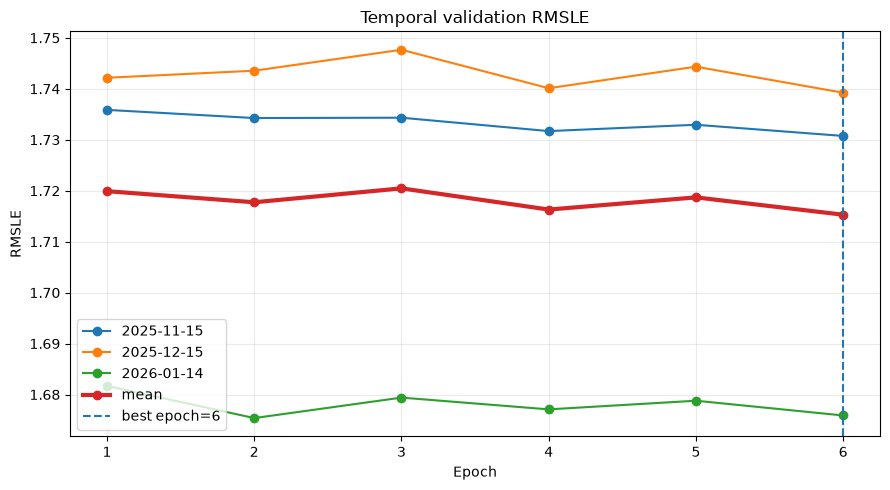

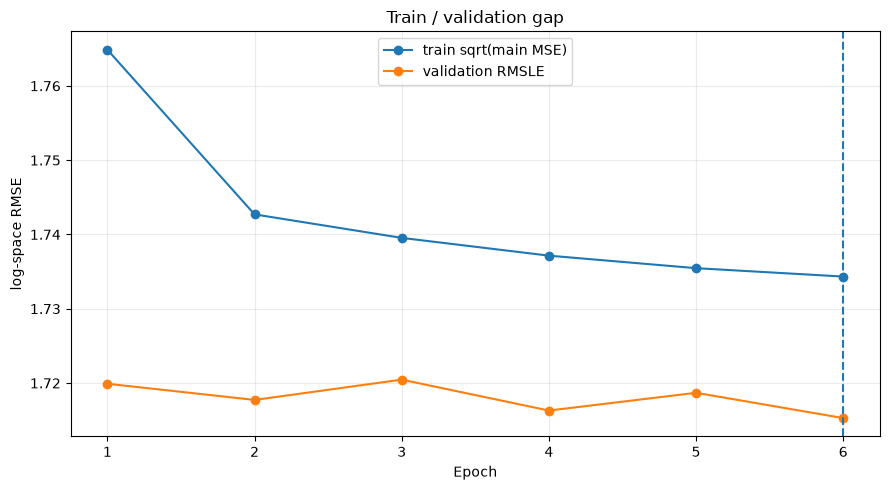

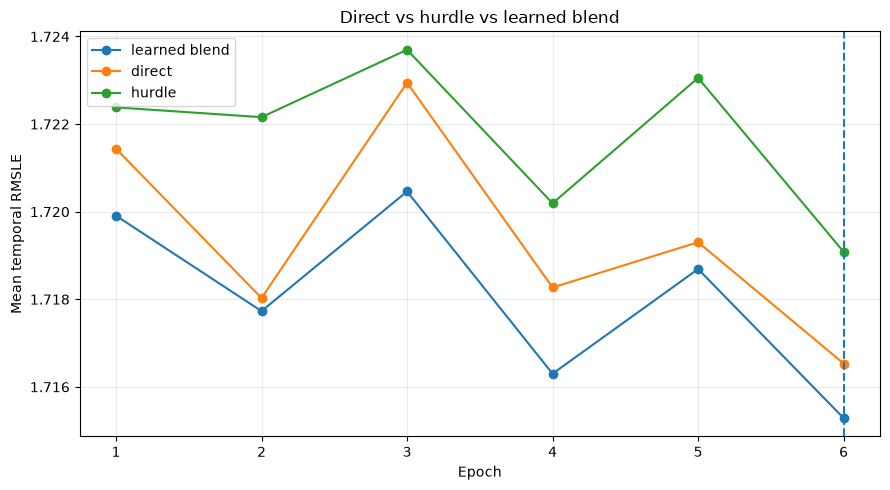

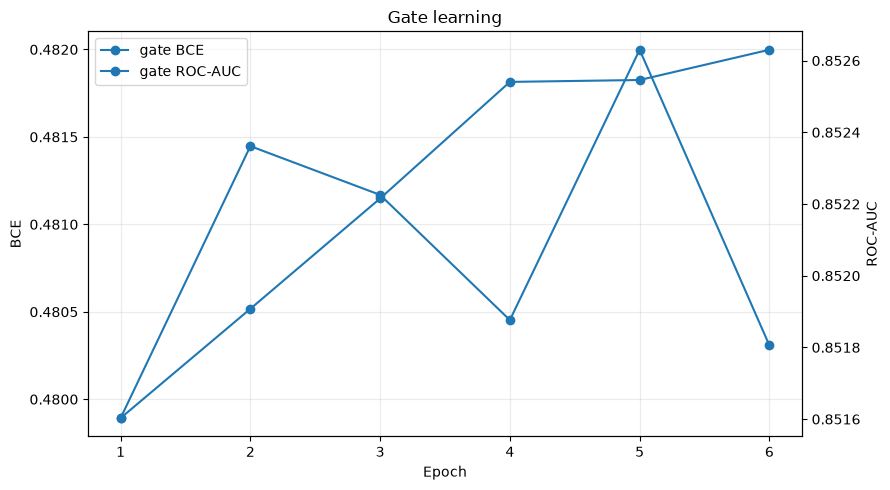

In [8]:
# RMSLE по temporal fold.
fig, ax = plt.subplots(figsize=(9, 5))
for cutoff, part in cv_df.groupby("valid_cutoff"):
    part = part.sort_values("epoch")
    ax.plot(part["epoch"], part["rmsle"], marker="o", label=cutoff)

mean_curve = cv_df.groupby("epoch")["rmsle"].mean().sort_index()
ax.plot(mean_curve.index, mean_curve.values, marker="o", linewidth=3, label="mean")
ax.axvline(BEST_EPOCH, linestyle="--", label=f"best epoch={BEST_EPOCH}")
ax.set_xlabel("Epoch")
ax.set_ylabel("RMSLE")
ax.set_title("Temporal validation RMSLE")
ax.legend()
ax.grid(alpha=0.25)
plt.tight_layout()
fig.savefig(MODEL_DIR / "cv_rmsle_curve.png", dpi=160, bbox_inches="tight")
plt.show()

# Train vs validation.
fig, ax = plt.subplots(figsize=(9, 5))
train_mean = cv_df.groupby("epoch")["train_rmsle_proxy"].mean().sort_index()
valid_mean = cv_df.groupby("epoch")["rmsle"].mean().sort_index()
ax.plot(train_mean.index, train_mean.values, marker="o", label="train sqrt(main MSE)")
ax.plot(valid_mean.index, valid_mean.values, marker="o", label="validation RMSLE")
ax.axvline(BEST_EPOCH, linestyle="--")
ax.set_xlabel("Epoch")
ax.set_ylabel("log-space RMSE")
ax.set_title("Train / validation gap")
ax.legend()
ax.grid(alpha=0.25)
plt.tight_layout()
fig.savefig(MODEL_DIR / "train_validation_gap.png", dpi=160, bbox_inches="tight")
plt.show()

# Direct vs hurdle vs blend.
fig, ax = plt.subplots(figsize=(9, 5))
curve = cv_df.groupby("epoch")[["rmsle", "direct_rmsle", "hurdle_rmsle"]].mean().sort_index()
ax.plot(curve.index, curve["rmsle"], marker="o", label="learned blend")
ax.plot(curve.index, curve["direct_rmsle"], marker="o", label="direct")
ax.plot(curve.index, curve["hurdle_rmsle"], marker="o", label="hurdle")
ax.axvline(BEST_EPOCH, linestyle="--")
ax.set_xlabel("Epoch")
ax.set_ylabel("Mean temporal RMSLE")
ax.set_title("Direct vs hurdle vs learned blend")
ax.legend()
ax.grid(alpha=0.25)
plt.tight_layout()
fig.savefig(MODEL_DIR / "direct_hurdle_blend_curve.png", dpi=160, bbox_inches="tight")
plt.show()

# Gate BCE/AUC.
fig, ax = plt.subplots(figsize=(9, 5))
gate_curve = cv_df.groupby("epoch")[["gate_bce", "gate_auc"]].mean().sort_index()
line1 = ax.plot(gate_curve.index, gate_curve["gate_bce"], marker="o", label="gate BCE")
ax.set_xlabel("Epoch")
ax.set_ylabel("BCE")
ax2 = ax.twinx()
line2 = ax2.plot(gate_curve.index, gate_curve["gate_auc"], marker="o", label="gate ROC-AUC")
ax2.set_ylabel("ROC-AUC")
ax.set_title("Gate learning")
ax.grid(alpha=0.25)
lines = line1 + line2
ax.legend(lines, [line.get_label() for line in lines], loc="best")
plt.tight_layout()
fig.savefig(MODEL_DIR / "gate_learning_curve.png", dpi=160, bbox_inches="tight")
plt.show()

## Error analysis на January fold

January -- последний out-of-time fold.

Смотрю:

- `true vs pred` в `log1p`;
- residual distribution;
- RMSLE отдельно для нулей и positive-квинтилей;
- calibration gate;
- самые большие ошибки.

Главная проблема остается в верхнем positive tail -- крупный будущий GMV модель чаще недооценивает.

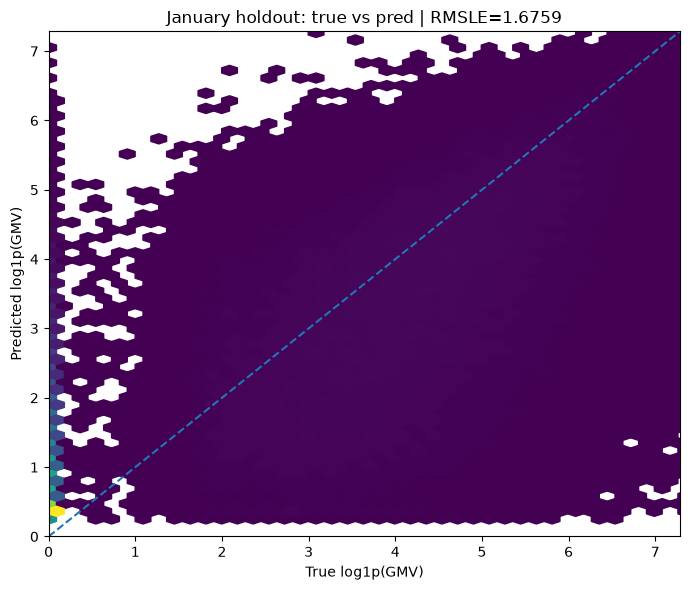

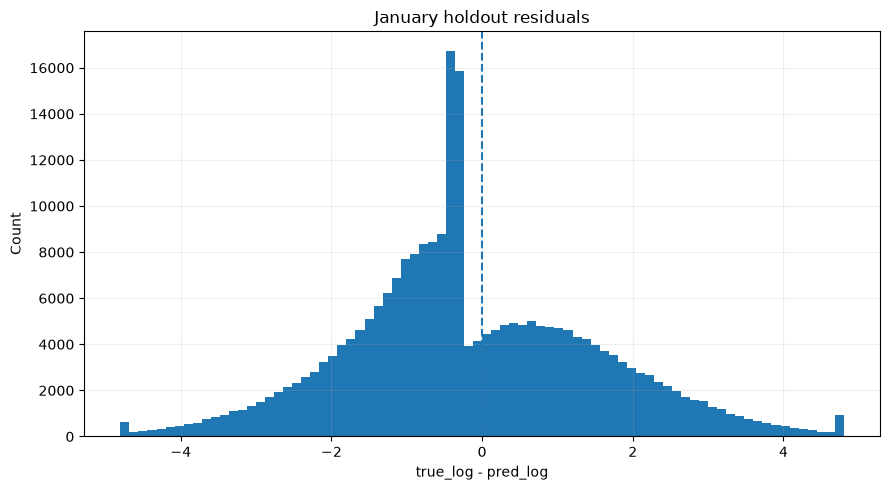

,segment,n,share,rmsle,mean_true_log,mean_pred_log,mean_residual
0,zero,114835,0.459340,1.709105,0.000000,1.383271,-1.383271
1,positive_Q1,27033,0.108132,1.201635,2.297012,2.351647,-0.054635
2,positive_Q2,27033,0.108132,1.367789,3.374946,2.719779,0.655167
3,positive_Q3,27033,0.108132,1.590989,4.134425,3.135563,0.998863
4,positive_Q4,27033,0.108132,1.779053,4.881981,3.644914,1.237067
5,positive_Q5,27033,0.108132,2.134084,6.046467,4.435305,1.611162


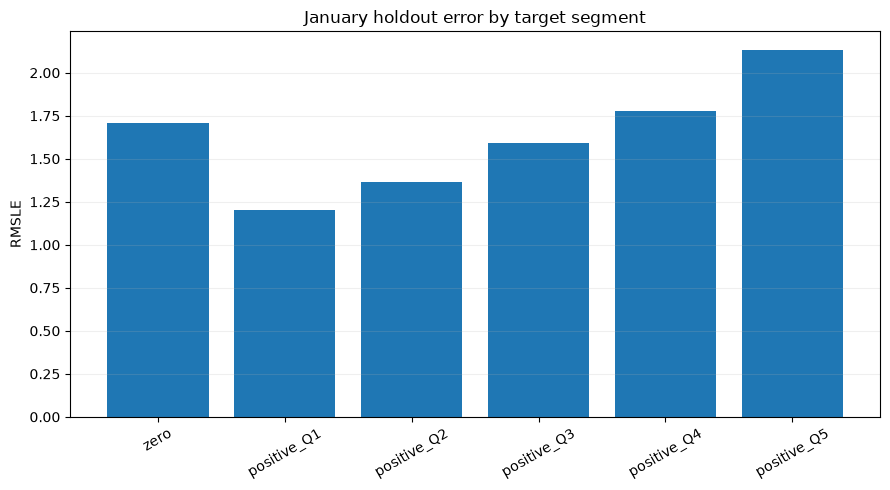

,bin,mean_pred,actual_rate,n
0,"(-0.001, 0.1]",0.092863,0.052119,8423
1,"(0.1, 0.2]",0.137171,0.109719,32410
2,"(0.2, 0.3]",0.251312,0.222209,25107
3,"(0.3, 0.4]",0.349108,0.330961,25154
4,"(0.4, 0.5]",0.449240,0.440590,22370
5,"(0.5, 0.6]",0.549117,0.536771,20206
6,"(0.6, 0.7]",0.649562,0.636006,19058
7,"(0.7, 0.8]",0.750027,0.725090,18537
8,"(0.8, 0.9]",0.851871,0.805573,20959
9,"(0.9, 1.0]",0.971414,0.936687,57776


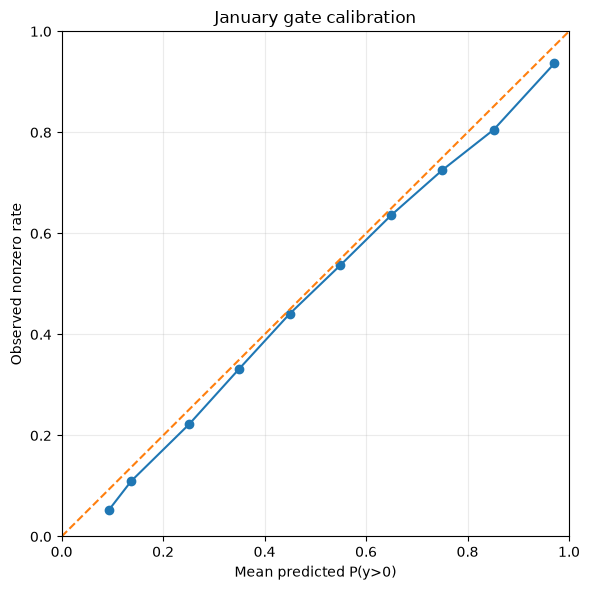

,user_id,y_true,y_pred,target_log,pred_log,residual_log,gate_prob,positive_log,direct_log,hurdle_log
97486,355760,5408.919922,0.516768,8.595989,0.416582,8.179407,0.122571,3.459708,0.408049,0.424059
134849,493918,3135.526123,0.458514,8.050871,0.377418,7.673453,0.109663,3.513121,0.368469,0.385260
144510,529470,2500.391846,0.508842,7.824603,0.411342,7.413260,0.119657,3.491986,0.403925,0.417842
104772,382829,3390.785645,1.549617,8.129112,0.935943,7.193169,0.261003,3.466344,0.971568,0.904726
182459,669690,1844.452148,0.409269,7.520480,0.343071,7.177408,0.103374,3.398586,0.333650,0.351327
74316,270681,9160.305664,6.086214,9.122744,1.958151,7.164592,0.438394,4.221069,2.081010,1.850492
146145,535525,3265.386475,1.659688,8.091439,0.978209,7.113230,0.270421,3.478963,1.020916,0.940786
84543,307751,1799.476929,0.551228,7.495807,0.439047,7.056760,0.127758,3.478710,0.432901,0.444432
2476,9355,0.000000,1151.195679,0.000000,7.049425,-7.049425,0.999852,7.114582,6.976270,7.113528
86405,314582,1606.091431,0.434187,7.382181,0.360598,7.021583,0.106442,3.483648,0.348948,0.370807


In [9]:
best_pred = last_fold_prediction_store[BEST_EPOCH]

target_log = np.log1p(last_fold_y)
pred_log = np.clip(best_pred["pred_log"], 0, None)
pred_value = np.expm1(pred_log)

diag = pd.DataFrame({
    "user_id": last_fold_users,
    "y_true": last_fold_y,
    "y_pred": pred_value,
    "target_log": target_log,
    "pred_log": pred_log,
    "residual_log": target_log - pred_log,
    "sq_error_log": (target_log - pred_log) ** 2,
    "gate_prob": best_pred["gate_prob"],
    "positive_log": best_pred["positive_log"],
    "direct_log": best_pred["direct_log"],
    "hurdle_log": best_pred["hurdle_log"],
})
diag.to_csv(MODEL_DIR / "jan_holdout_diagnostics.csv", index=False)

# True vs pred в log1p.
fig, ax = plt.subplots(figsize=(7, 6))
ax.hexbin(diag["target_log"], diag["pred_log"], gridsize=60, mincnt=1)
limit = float(max(
    diag["target_log"].quantile(0.995),
    diag["pred_log"].quantile(0.995),
))
ax.plot([0, limit], [0, limit], linestyle="--")
ax.set_xlim(0, limit)
ax.set_ylim(0, limit)
ax.set_xlabel("True log1p(GMV)")
ax.set_ylabel("Predicted log1p(GMV)")
ax.set_title(f"January holdout: true vs pred | RMSLE={JAN_RMSLE:.4f}")
plt.tight_layout()
fig.savefig(MODEL_DIR / "jan_true_vs_pred.png", dpi=160, bbox_inches="tight")
plt.show()

# Распределение residual.
fig, ax = plt.subplots(figsize=(9, 5))
clip = float(np.quantile(np.abs(diag["residual_log"]), 0.995))
ax.hist(diag["residual_log"].clip(-clip, clip), bins=80)
ax.axvline(0.0, linestyle="--")
ax.set_xlabel("true_log - pred_log")
ax.set_ylabel("Count")
ax.set_title("January holdout residuals")
ax.grid(alpha=0.20)
plt.tight_layout()
fig.savefig(MODEL_DIR / "jan_residual_hist.png", dpi=160, bbox_inches="tight")
plt.show()

# Нули + positive-квинтили.
diag["segment"] = "zero"
positive_idx = diag["y_true"] > 0
positive_rank = diag.loc[positive_idx, "target_log"].rank(method="first")
diag.loc[positive_idx, "segment"] = pd.qcut(
    positive_rank,
    q=5,
    labels=["positive_Q1", "positive_Q2", "positive_Q3", "positive_Q4", "positive_Q5"],
).astype(str)

segment_order = [
    "zero",
    "positive_Q1",
    "positive_Q2",
    "positive_Q3",
    "positive_Q4",
    "positive_Q5",
]

segment_rows = []
for segment in segment_order:
    part = diag[diag["segment"] == segment]
    if len(part) == 0:
        continue
    segment_rows.append({
        "segment": segment,
        "n": len(part),
        "share": len(part) / len(diag),
        "rmsle": float(np.sqrt(part["sq_error_log"].mean())),
        "mean_true_log": float(part["target_log"].mean()),
        "mean_pred_log": float(part["pred_log"].mean()),
        "mean_residual": float(part["residual_log"].mean()),
    })

segment_df = pd.DataFrame(segment_rows)
display(segment_df)

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(segment_df["segment"], segment_df["rmsle"])
ax.set_ylabel("RMSLE")
ax.set_title("January holdout error by target segment")
ax.tick_params(axis="x", rotation=30)
ax.grid(axis="y", alpha=0.20)
plt.tight_layout()
fig.savefig(MODEL_DIR / "jan_segment_rmsle.png", dpi=160, bbox_inches="tight")
plt.show()

# Calibration gate.
calibration = pd.DataFrame({
    "p": diag["gate_prob"],
    "nonzero": (diag["y_true"] > 0).astype(float),
})
calibration["bin"] = pd.cut(
    calibration["p"],
    bins=np.linspace(0, 1, 11),
    include_lowest=True,
)
calibration_df = (
    calibration.groupby("bin", observed=True)
    .agg(
        mean_pred=("p", "mean"),
        actual_rate=("nonzero", "mean"),
        n=("nonzero", "size"),
    )
    .reset_index()
)
display(calibration_df)

fig, ax = plt.subplots(figsize=(6, 6))
ax.plot(calibration_df["mean_pred"], calibration_df["actual_rate"], marker="o")
ax.plot([0, 1], [0, 1], linestyle="--")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_xlabel("Mean predicted P(y>0)")
ax.set_ylabel("Observed nonzero rate")
ax.set_title("January gate calibration")
ax.grid(alpha=0.25)
plt.tight_layout()
fig.savefig(MODEL_DIR / "jan_gate_calibration.png", dpi=160, bbox_inches="tight")
plt.show()

worst_errors = (
    diag.assign(abs_error=lambda x: np.abs(x["residual_log"]))
    .sort_values("abs_error", ascending=False)
    .head(30)
    [[
        "user_id",
        "y_true",
        "y_pred",
        "target_log",
        "pred_log",
        "residual_log",
        "gate_prob",
        "positive_log",
        "direct_log",
        "hurdle_log",
    ]]
)
display(worst_errors)

## Screening перед final train

Перед двумя финальными seed сравниваю January RMSLE с прошлой сильной LSTM.

Reference -- `1.679061`.

Если новый January хуже reference больше чем на `0.015`, final train можно автоматически пропустить.

В этом run:

`1.675888 < 1.679061`

Final train запускаю.

In [10]:
jan_limit = REFERENCE_JAN_HOLDOUT_RMSLE + MAX_JAN_DEGRADATION_FOR_FINAL
passes_jan_screen = JAN_RMSLE <= jan_limit

last_epoch_mean = float(
    cv_df[cv_df["epoch"] == MAX_CV_EPOCHS]["rmsle"].mean()
)
overfit_from_best_to_last = last_epoch_mean - CV_RMSLE

print("reference January RMSLE:", f"{REFERENCE_JAN_HOLDOUT_RMSLE:.6f}")
print("screen limit:", f"{jan_limit:.6f}")
print("new January RMSLE:", f"{JAN_RMSLE:.6f}")
print("mean CV RMSLE:", f"{CV_RMSLE:.6f}")
print("best->last mean validation delta:", f"{overfit_from_best_to_last:+.6f}")

if BEST_EPOCH <= 2:
    print(
        "NOTE: optimum is very early. Это допустимо, но быстрая temporal overfit остается возможной."
    )

if CV_STD > 0.04:
    print("WARNING: fold-to-fold variance high:", f"{CV_STD:.4f}")

SHOULD_RUN_FINAL = (
    FORCE_FINAL_TRAIN
    or not AUTO_SKIP_FINAL_IF_WEAK
    or passes_jan_screen
)

print("FINAL TRAIN:", "ENABLED" if SHOULD_RUN_FINAL else "SKIPPED")

reference January RMSLE: 1.679061
screen limit: 1.694061
new January RMSLE: 1.675888
mean CV RMSLE: 1.715288
best->last mean validation delta: +0.000000
FINAL TRAIN: ENABLED


## Финальное обучение

После CV фиксирую `BEST_EPOCH=6`.

Дальше:

- возвращаю в train все 10 labeled cutoff;
- обучаю два seed -- `42` и `143`;
- после каждой эпохи сохраняю resume checkpoint;
- после 6-й эпохи сохраняю финальные веса каждого seed;
- на inference усредняю `pred_log` двух моделей;
- только после усреднения делаю `expm1`.

Так ensemble остается в том же пространстве, в котором считается RMSLE.

In [10]:
final_static_stats = fit_static_stats(LABELED_CUTOFFS)
final_known_user_mask = known_user_mask_from_cutoffs(LABELED_CUTOFFS)
final_models = []


def _load_resume(path, map_location="cpu"):
    try:
        return torch.load(path, map_location=map_location, weights_only=False)
    except TypeError:
        return torch.load(path, map_location=map_location)


def _save_resume_checkpoint(
    path,
    seed,
    epoch,
    model,
    optimizer,
    scheduler,
    scaler,
    history,
):
    path.parent.mkdir(parents=True, exist_ok=True)

    payload = {
        "architecture": "JointHurdleLSTM-v4-robust",
        "seed": int(seed),
        "epoch": int(epoch),
        "best_epoch": int(BEST_EPOCH),
        "model_kwargs": MODEL_KWARGS,
        "state_dict": {
            k: v.detach().cpu()
            for k, v in model.state_dict().items()
        },
        "optimizer_state_dict": optimizer.state_dict(),
        "scheduler_state_dict": scheduler.state_dict(),
        "scaler_state_dict": scaler.state_dict() if scaler is not None else None,
        "history": history,
    }

    tmp = path.with_suffix(".tmp")
    torch.save(payload, tmp)
    tmp.replace(path)


def _save_final_seed(model, path, seed):
    path.parent.mkdir(parents=True, exist_ok=True)
    torch.save(
        {
            "architecture": "JointHurdleLSTM-v4-robust",
            "seed": int(seed),
            "model_kwargs": MODEL_KWARGS,
            "state_dict": {
                k: v.detach().cpu()
                for k, v in model.state_dict().items()
            },
        },
        path,
    )


if SHOULD_RUN_FINAL:
    for seed in FINAL_SEEDS:
        print("\n" + "=" * 100)
        print("FINAL SEED:", seed)

        seed_dir = MODEL_DIR / f"seed_{seed}"
        seed_dir.mkdir(parents=True, exist_ok=True)

        resume_path = seed_dir / "resume.pt"
        final_path = seed_dir / "model.pt"
        history_path = seed_dir / "history.json"

        # Готовый seed не переобучаю.
        if final_path.exists():
            print(f"seed {seed}: final model already exists -> skip")
            checkpoint = _load_resume(final_path, map_location=DEVICE)
            model = JointHurdleLSTM(**checkpoint["model_kwargs"]).to(DEVICE)
            model.load_state_dict(checkpoint["state_dict"], strict=True)
            model.eval()

            history = (
                json.loads(history_path.read_text(encoding="utf-8"))
                if history_path.exists()
                else []
            )
            final_models.append((seed, model, history))
            continue

        set_seed(seed)

        train_loader = make_loader(
            LABELED_CUTOFFS,
            shuffle=True,
            known_user_mask=final_known_user_mask,
        )

        model = JointHurdleLSTM(**MODEL_KWARGS).to(DEVICE)
        optimizer = make_optimizer(model)
        scaler = new_grad_scaler()

        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
            optimizer,
            T_max=max(BEST_EPOCH, 1),
            eta_min=2e-5,
        )

        history = []
        start_epoch = 1

        # После падения продолжаю с последней сохраненной эпохи.
        if resume_path.exists():
            checkpoint = _load_resume(resume_path, map_location=DEVICE)

            if checkpoint.get("architecture") != "JointHurdleLSTM-v4-robust":
                raise RuntimeError(f"Unexpected resume checkpoint for seed {seed}")

            if int(checkpoint["best_epoch"]) != int(BEST_EPOCH):
                raise RuntimeError(
                    f"Resume BEST_EPOCH={checkpoint['best_epoch']} != current {BEST_EPOCH}"
                )

            model.load_state_dict(checkpoint["state_dict"], strict=True)
            optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
            scheduler.load_state_dict(checkpoint["scheduler_state_dict"])

            if scaler is not None and checkpoint.get("scaler_state_dict") is not None:
                scaler.load_state_dict(checkpoint["scaler_state_dict"])

            history = checkpoint.get("history", [])
            start_epoch = int(checkpoint["epoch"]) + 1

            print(
                f"RESUME: epoch {checkpoint['epoch']} already completed "
                f"-> start from {start_epoch}"
            )

        for epoch in range(start_epoch, BEST_EPOCH + 1):
            train_metrics = train_one_epoch(
                model,
                train_loader,
                optimizer,
                final_static_stats,
                scaler,
            )
            scheduler.step()

            history.append({
                "epoch": int(epoch),
                **{
                    k: float(v)
                    for k, v in train_metrics.items()
                },
            })

            _save_resume_checkpoint(
                resume_path,
                seed,
                epoch,
                model,
                optimizer,
                scheduler,
                scaler,
                history,
            )

            history_path.write_text(
                json.dumps(history, ensure_ascii=False, indent=2),
                encoding="utf-8",
            )

            print(
                f"epoch {epoch:02d}/{BEST_EPOCH:02d} | "
                f"loss={train_metrics['loss']:.5f} | "
                f"main_RMSE={np.sqrt(max(train_metrics['main_mse'], 0)):.5f} | "
                "checkpoint SAVED"
            )

        _save_final_seed(model, final_path, seed)
        print("FINAL WEIGHTS SAVED:", final_path)

        final_models.append((seed, model, history))

else:
    print("No final models trained.")


FINAL SEED: 42
epoch 01/06 | loss=3.40028 | main_RMSE=1.75551 | checkpoint SAVED
epoch 02/06 | loss=3.31586 | main_RMSE=1.73624 | checkpoint SAVED
epoch 03/06 | loss=3.30324 | main_RMSE=1.73323 | checkpoint SAVED
epoch 04/06 | loss=3.29271 | main_RMSE=1.73061 | checkpoint SAVED
epoch 05/06 | loss=3.28644 | main_RMSE=1.72904 | checkpoint SAVED
epoch 06/06 | loss=3.28235 | main_RMSE=1.72802 | checkpoint SAVED
FINAL WEIGHTS SAVED: /Users/pinta/Dev/E-CUP-2026/models/lstm_hurdle_v4_robust/seed_42/model.pt

FINAL SEED: 143
epoch 01/06 | loss=3.40172 | main_RMSE=1.75581 | checkpoint SAVED
epoch 02/06 | loss=3.31408 | main_RMSE=1.73583 | checkpoint SAVED
epoch 03/06 | loss=3.30188 | main_RMSE=1.73294 | checkpoint SAVED
epoch 04/06 | loss=3.29351 | main_RMSE=1.73089 | checkpoint SAVED
epoch 05/06 | loss=3.28587 | main_RMSE=1.72895 | checkpoint SAVED
epoch 06/06 | loss=3.28174 | main_RMSE=1.72794 | checkpoint SAVED
FINAL WEIGHTS SAVED: /Users/pinta/Dev/E-CUP-2026/models/lstm_hurdle_v4_robust/se

## Сохранение artifacts

Сохраняю:

- веса каждого final seed;
- primary `model.pt`;
- static mean/std;
- `meta.json`;
- список `all_user_ids`;
- CV history и summary;
- config с архитектурой и флагами.

Resume checkpoint каждого seed обновляется после каждой эпохи.

In [13]:
def save_checkpoint(model, path, seed):
    path.parent.mkdir(parents=True, exist_ok=True)
    payload = {
        "architecture": "JointHurdleLSTM-v4-robust",
        "seed": int(seed),
        "model_kwargs": MODEL_KWARGS,
        "state_dict": {k: v.detach().cpu() for k, v in model.state_dict().items()},
    }
    torch.save(payload, path)


meta_bytes = (DATA_DIR / "meta.json").read_bytes()

cv_df.to_csv(MODEL_DIR / "cv_history.csv", index=False)
cv_summary.to_csv(MODEL_DIR / "cv_summary.csv", index=False)

shutil.copy2(DATA_DIR / "meta.json", MODEL_DIR / "data_meta.json")
shutil.copy2(DATA_DIR / "all_user_ids.npy", MODEL_DIR / "all_user_ids.npy")

if final_models:
    for seed, model, history in final_models:
        save_checkpoint(
            model,
            MODEL_DIR / f"seed_{seed}" / "model.pt",
            seed,
        )

    primary_seed, primary_model, _ = final_models[0]
    save_checkpoint(primary_model, MODEL_DIR / "model.pt", primary_seed)

    torch.save(
        {
            "mean": final_static_stats[0].cpu(),
            "std": final_static_stats[1].cpu(),
            "selected_static_features": STATIC_FEATURES,
        },
        MODEL_DIR / "static_stats.pt",
    )

config = {
    "architecture": "JointHurdleLSTM-v4-robust",
    "data_format_version": META["format_version"],
    "data_meta_sha256": hashlib.sha256(meta_bytes).hexdigest(),
    "model_kwargs": MODEL_KWARGS,
    "static_features": STATIC_FEATURES,
    "flags": {
        "use_user_embedding": USE_USER_EMBEDDING,
        "use_conv_stem": USE_CONV_STEM,
        "use_absolute_time": USE_ABSOLUTE_TIME,
        "use_future_calendar_static": USE_FUTURE_CALENDAR_STATIC,
        "use_cutoff_seasonal_static": USE_CUTOFF_SEASONAL_STATIC,
    },
    "optimizer": "AdamW",
    "lr": LR,
    "embedding_lr": EMBED_LR,
    "weight_decay": WEIGHT_DECAY,
    "embedding_weight_decay": EMBED_WEIGHT_DECAY,
    "aux_weights": {
        "gate": AUX_GATE_WEIGHT,
        "positive": AUX_POS_WEIGHT,
        "direct": AUX_DIRECT_WEIGHT,
    },
    "cv_valid_cutoffs": CV_VALID_CUTOFFS,
    "best_epoch": BEST_EPOCH,
    "mean_temporal_cv_rmsle": CV_RMSLE,
    "cv_std_rmsle": CV_STD,
    "january_rmsle": JAN_RMSLE,
    "reference_january_rmsle": REFERENCE_JAN_HOLDOUT_RMSLE,
    "screen_limit": jan_limit,
    "final_train_ran": bool(final_models),
    "final_seeds": FINAL_SEEDS if final_models else [],
    "prediction_space": "log1p",
    "final_ensemble": (
        "mean pred_log across seeds, then expm1"
        if final_models
        else None
    ),
    "sequence_input_size": SEQ_INPUT_SIZE,
    "short_summary_size": SHORT_SUMMARY_SIZE,
    "static_input_size": STATIC_INPUT_SIZE,
}

with open(MODEL_DIR / "config.json", "w", encoding="utf-8") as f:
    json.dump(config, f, ensure_ascii=False, indent=2)

print("saved artifacts to:", MODEL_DIR)

saved artifacts to: /Users/pinta/Dev/E-CUP-2026/models/lstm_hurdle_v4_robust


## Inference и submission

Для каждого seed считаю `pred_log` на `2026-02-13`.

Финальный prediction:

`mean(pred_log_seed_1, pred_log_seed_2) -> expm1`

Проверяю:

- нет `NaN`;
- нет `inf`;
- нет отрицательных prediction;
- есть prediction для всех 250000 пользователей.

In [14]:
if final_models:
    seed_pred_logs = []
    submission_user_ids = None

    for seed, model, _ in final_models:
        user_ids, pred, _ = predict_model(
            model,
            INFERENCE_CUTOFF,
            final_static_stats,
            final_known_user_mask,
            with_target=False,
        )
        seed_pred_logs.append(np.clip(pred["pred_log"], 0, None))
        submission_user_ids = user_ids

    ensemble_pred_log = np.mean(np.stack(seed_pred_logs, axis=0), axis=0)
    raw_pred = np.expm1(ensemble_pred_log)

    submission = pd.read_csv(PROJECT_ROOT / "data" / "sample_submit.csv")
    pred_map = pd.Series(raw_pred, index=submission_user_ids)
    submission["predict"] = submission["user_id"].map(pred_map)

    if submission["predict"].isna().any():
        raise AssertionError(
            f"Missing predictions: {int(submission['predict'].isna().sum())}"
        )
    if not np.isfinite(submission["predict"]).all():
        raise AssertionError("Non-finite predictions")
    if (submission["predict"] < 0).any():
        raise AssertionError("Negative predictions are forbidden")

    out_path = SUBMISSION_DIR / "lstm_hurdle_v4_robust.csv"
    submission.to_csv(out_path, index=False)

    print("saved:", out_path)
    print("rows:", len(submission))
    print("exact zeros:", f"{(submission['predict'] == 0).mean():.2%}")
    display(submission.head())
else:
    print("Submission skipped because final training was skipped.")

saved: /Users/pinta/Dev/E-CUP-2026/submissions/lstm_hurdle_v4_robust.csv
rows: 250000
exact zeros: 0.00%


,user_id,predict
0,2,2.098345
1,7,77.271141
2,15,6.250083
3,18,123.293556
4,23,0.370146


## Reload smoke-test

После сохранения заново загружаю model + static stats и делаю forward на одном batch.

Проверяю конечность:

- `pred_log`;
- `gate_prob`;
- `positive_log`;
- `direct_log`.

In [15]:
def safe_torch_load(path, map_location="cpu"):
    try:
        return torch.load(path, map_location=map_location, weights_only=True)
    except TypeError:
        return torch.load(path, map_location=map_location)


def load_saved_model(path):
    checkpoint = safe_torch_load(path, map_location=DEVICE)
    if checkpoint.get("architecture") != "JointHurdleLSTM-v4-robust":
        raise RuntimeError("Unexpected checkpoint architecture")

    model = JointHurdleLSTM(**checkpoint["model_kwargs"]).to(DEVICE)
    model.load_state_dict(checkpoint["state_dict"], strict=True)
    model.eval()
    return model


if final_models:
    saved_stats = safe_torch_load(MODEL_DIR / "static_stats.pt", map_location="cpu")
    loaded_stats = (saved_stats["mean"], saved_stats["std"])
    loaded_model = load_saved_model(MODEL_DIR / "model.pt")

    smoke_dataset = HybridDataset(
        INFERENCE_CUTOFF,
        with_target=False,
        known_user_mask=final_known_user_mask,
    )
    smoke_loader = DataLoader(
        smoke_dataset,
        batch_size=min(256, BATCH_SIZE),
        shuffle=False,
        num_workers=0,
    )
    smoke_batch = next(iter(smoke_loader))

    sequence, static, user_index, user_known, history_length, _ = unpack_batch(
        smoke_batch,
        with_target=False,
    )
    static = normalize_static(static, loaded_stats)

    with torch.no_grad():
        out = loaded_model(
            sequence,
            static,
            user_index,
            user_known,
            history_length,
        )

    for key in ["pred_log", "gate_prob", "positive_log", "direct_log"]:
        assert torch.isfinite(out[key]).all(), key

    print("reload smoke-test passed:", len(out["pred_log"]), "rows")
    print("saved hurdle weight:", float(out["hurdle_weight"].cpu()))
    print("saved user scale:", float(out["user_scale"].cpu()))
else:
    print("Reload test skipped: no final checkpoint was trained.")

reload smoke-test passed: 256 rows
saved hurdle weight: 0.5284940600395203
saved user scale: 0.0


## Итог

Temporal CV:

- mean RMSLE -- `1.715288`;
- January RMSLE -- `1.675888`;
- лучшая эпоха -- `6`.

Public leaderboard:

- предыдущая лучшая LSTM -- `1.6529693117`;
- Joint Hurdle BiLSTM -- **`1.6509102971`**;
- улучшение -- **`0.0020590146` RMSLE**.

Это текущий лучший public score команды.

Следующие ablation имеет смысл проверять по одному:

1. `USE_USER_EMBEDDING=True`;
2. `USE_FUTURE_CALENDAR_STATIC=True`;
3. `USE_CONV_STEM=True`.

Все сразу не включаю -- иначе непонятно, что реально изменило score.